In [8]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201, VGG16, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split

In [3]:
input_dir = './data/'
img_size = (224, 224)
batch_size = 32
num_classes = 10  # Adjust if labels range from 0-10

# Extract labels from filenames
data = []
labels = []

for file in os.listdir(input_dir):
    if file.endswith('.png'):
        label = int(file.split('_')[0])
        data.append(os.path.join(input_dir, file))
        labels.append(label)

# Convert to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Split data
train_files, val_files, train_labels, val_labels = train_test_split(data, labels, test_size=0.2, stratify=labels, random_state=42)

# Preprocessing function
def preprocess_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, img_size) / 255.0
    return image, tf.one_hot(label, num_classes)

# Create datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_ds = train_ds.map(preprocess_image).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_files, val_labels))
val_ds = val_ds.map(preprocess_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Select a pre-trained model
base_model = DenseNet201(weights='imagenet', include_top=False, input_shape=img_size + (3,))
# base_model = VGG16(weights='imagenet', include_top=False, input_shape=img_size + (3,))
# base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=img_size + (3,))

# Freeze base model
base_model.trainable = False

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_best.keras', save_best_only=True, monitor='val_loss')

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)


# Save final model
model.save('final_model.h5')

74836368/74836368 [==============================] - 22s 0us/step
Epoch 1/20
35/35 [==============================] - 144s 4s/step - loss: 2.1082 - accuracy: 0.2777 - val_loss: 1.7938 - val_accuracy: 0.3964
Epoch 2/20
35/35 [==============================] - 119s 3s/step - loss: 1.4517 - accuracy: 0.5554 - val_loss: 1.3943 - val_accuracy: 0.5143
Epoch 3/20
35/35 [==============================] - 120s 3s/step - loss: 1.1195 - accuracy: 0.6795 - val_loss: 1.1501 - val_accuracy: 0.6179
Epoch 4/20
35/35 [==============================] - 126s 4s/step - loss: 0.8647 - accuracy: 0.7839 - val_loss: 0.9515 - val_accuracy: 0.7107
Epoch 5/20
35/35 [==============================] - 122s 3s/step - loss: 0.7469 - accuracy: 0.8098 - val_loss: 0.8826 - val_accuracy: 0.7286
Epoch 6/20
35/35 [==============================] - 123s 3s/step - loss: 0.6440 - accuracy: 0.8562 - val_loss: 0.7915 - val_accuracy: 0.7464
Epoch 7/20
35/35 [==============================] - 122s 3s/step - loss: 0.5811 - accura

In [4]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=img_size + (3,))

# Freeze base model
base_model.trainable = False

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_best.keras', save_best_only=True, monitor='val_loss')

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)

58889256/58889256 [==============================] - 18s 0us/step
Epoch 1/20
35/35 [==============================] - 122s 3s/step - loss: 2.3435 - accuracy: 0.1036 - val_loss: 2.2987 - val_accuracy: 0.1464
Epoch 2/20
35/35 [==============================] - 120s 3s/step - loss: 2.3128 - accuracy: 0.1107 - val_loss: 2.3018 - val_accuracy: 0.1500
Epoch 3/20
35/35 [==============================] - 117s 3s/step - loss: 2.3064 - accuracy: 0.1071 - val_loss: 2.3023 - val_accuracy: 0.1464
Epoch 4/20
35/35 [==============================] - 126s 4s/step - loss: 2.2874 - accuracy: 0.1286 - val_loss: 2.2801 - val_accuracy: 0.1393
Epoch 5/20
35/35 [==============================] - 120s 3s/step - loss: 2.2772 - accuracy: 0.1562 - val_loss: 2.2722 - val_accuracy: 0.1071
Epoch 6/20
35/35 [==============================] - 118s 3s/step - loss: 2.2706 - accuracy: 0.1473 - val_loss: 2.2726 - val_accuracy: 0.1643
Epoch 7/20
35/35 [==============================] - 118s 3s/step - loss: 2.2613 - accura

In [5]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=img_size + (3,))

# Freeze base model
base_model.trainable = False

# Add custom layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_best.keras', save_best_only=True, monitor='val_loss')

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)

9406464/9406464 [==============================] - 3s 0us/step
Epoch 1/20
35/35 [==============================] - 28s 644ms/step - loss: 2.0085 - accuracy: 0.3107 - val_loss: 1.5832 - val_accuracy: 0.4214
Epoch 2/20
35/35 [==============================] - 22s 614ms/step - loss: 1.2766 - accuracy: 0.5964 - val_loss: 1.2031 - val_accuracy: 0.6143
Epoch 3/20
35/35 [==============================] - 22s 613ms/step - loss: 0.9627 - accuracy: 0.6946 - val_loss: 1.0141 - val_accuracy: 0.6857
Epoch 4/20
35/35 [==============================] - 22s 619ms/step - loss: 0.7869 - accuracy: 0.7652 - val_loss: 0.8507 - val_accuracy: 0.7786
Epoch 5/20
35/35 [==============================] - 22s 619ms/step - loss: 0.6398 - accuracy: 0.8286 - val_loss: 0.7531 - val_accuracy: 0.7893
Epoch 6/20
35/35 [==============================] - 22s 617ms/step - loss: 0.5577 - accuracy: 0.8455 - val_loss: 0.6946 - val_accuracy: 0.7643
Epoch 7/20
35/35 [==============================] - 22s 622ms/step - loss: 0.47

9/9 [==============================] - 5s 461ms/step - loss: 0.4340 - accuracy: 0.8357
Test Loss: 0.43399661779403687
Test Accuracy: 83.57%


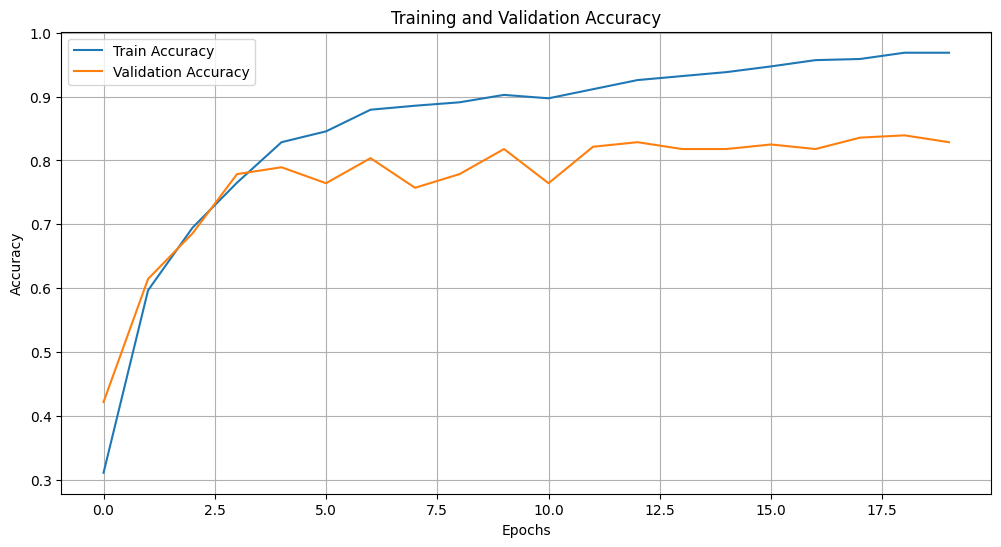

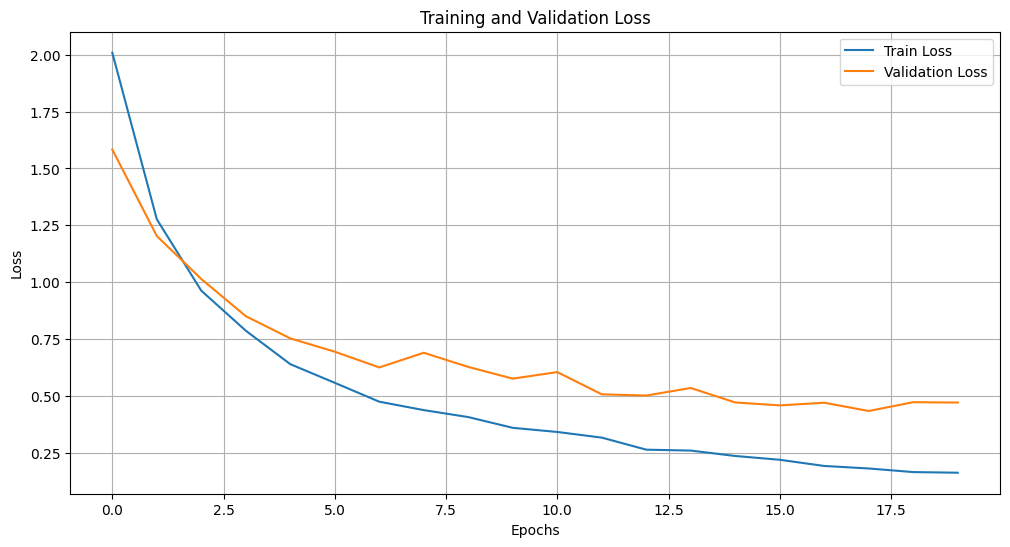

In [9]:
# Load the best model saved during training
best_model = tf.keras.models.load_model('model_best.keras')
test_loss, test_accuracy = best_model.evaluate(val_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

# Plot loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [10]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = best_model.evaluate(val_ds)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

9/9 [==============================] - 5s 501ms/step - loss: 0.4340 - accuracy: 0.8357
Test Loss: 0.43399661779403687
Test Accuracy: 83.57%


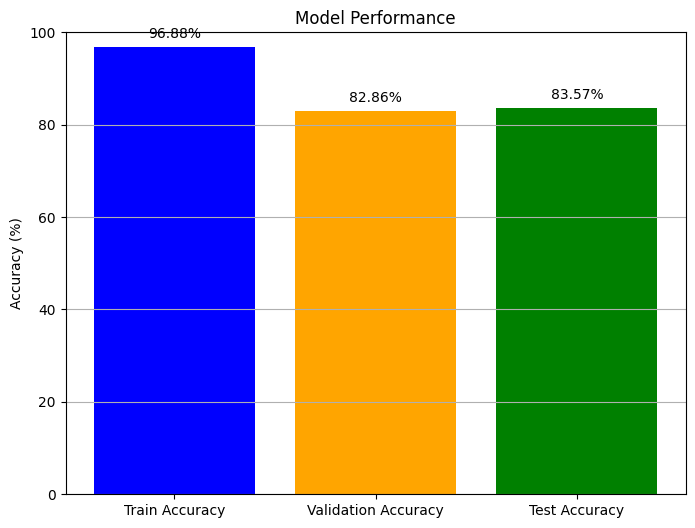

In [11]:
# Assuming test_accuracy is computed as shown in the previous step
train_acc = history.history['accuracy'][-1]  # Last training accuracy
val_acc = history.history['val_accuracy'][-1]  # Last validation accuracy

# Create a bar plot
plt.figure(figsize=(8, 6))
metrics = ['Train Accuracy', 'Validation Accuracy', 'Test Accuracy']
values = [train_acc * 100, val_acc * 100, test_accuracy * 100]  # Convert to percentages

plt.bar(metrics, values, color=['blue', 'orange', 'green'])
plt.title('Model Performance')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(values):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center')
plt.grid(axis='y')
plt.show()